<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


## Assignment: Exploring and Preparing Data


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage.

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.
<br>
En esta tarea, predeciremos si la primera etapa del Falcon 9 aterrizará con éxito. SpaceX anuncia en su sitio web lanzamientos de cohetes Falcon 9 con un costo de 62 millones de dólares; Otros proveedores cuestan más de 165 millones de dólares cada uno, gran parte del ahorro se debe al hecho de que SpaceX puede reutilizar la primera etapa.

En esta práctica de laboratorio, realizará análisis de datos exploratorios e ingeniería de funciones.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans.


## Objectives

Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

*   Exploratory Data Analysis
*   Preparing Data  Feature Engineering


### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab


In [3]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

In [4]:
# pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

## Exploratory Data Analysis


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


In [5]:
from js import fetch
import io

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp = await fetch(URL)
dataset_part_2_csv = io.BytesIO((await resp.arrayBuffer()).to_py())
df=pd.read_csv(dataset_part_2_csv)
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass also appears to be a factor; even with more massive payloads, the first stage often returns successfully.
<br>
Primero, intentemos ver cómo las variables `FlightNumber` (que indica los intentos de lanzamiento continuos) y `Payload` afectarían el resultado del lanzamiento.

Podemos trazar el <code>FlightNumber</code> frente a <code>PayloadMass</code> y superponer el resultado del lanzamiento. Vemos que a medida que aumenta el número de vuelos, es más probable que la primera etapa aterrice con éxito. La masa de la carga útil también parece ser un factor; Incluso con cargas útiles más masivas, la primera etapa suele regresar con éxito.


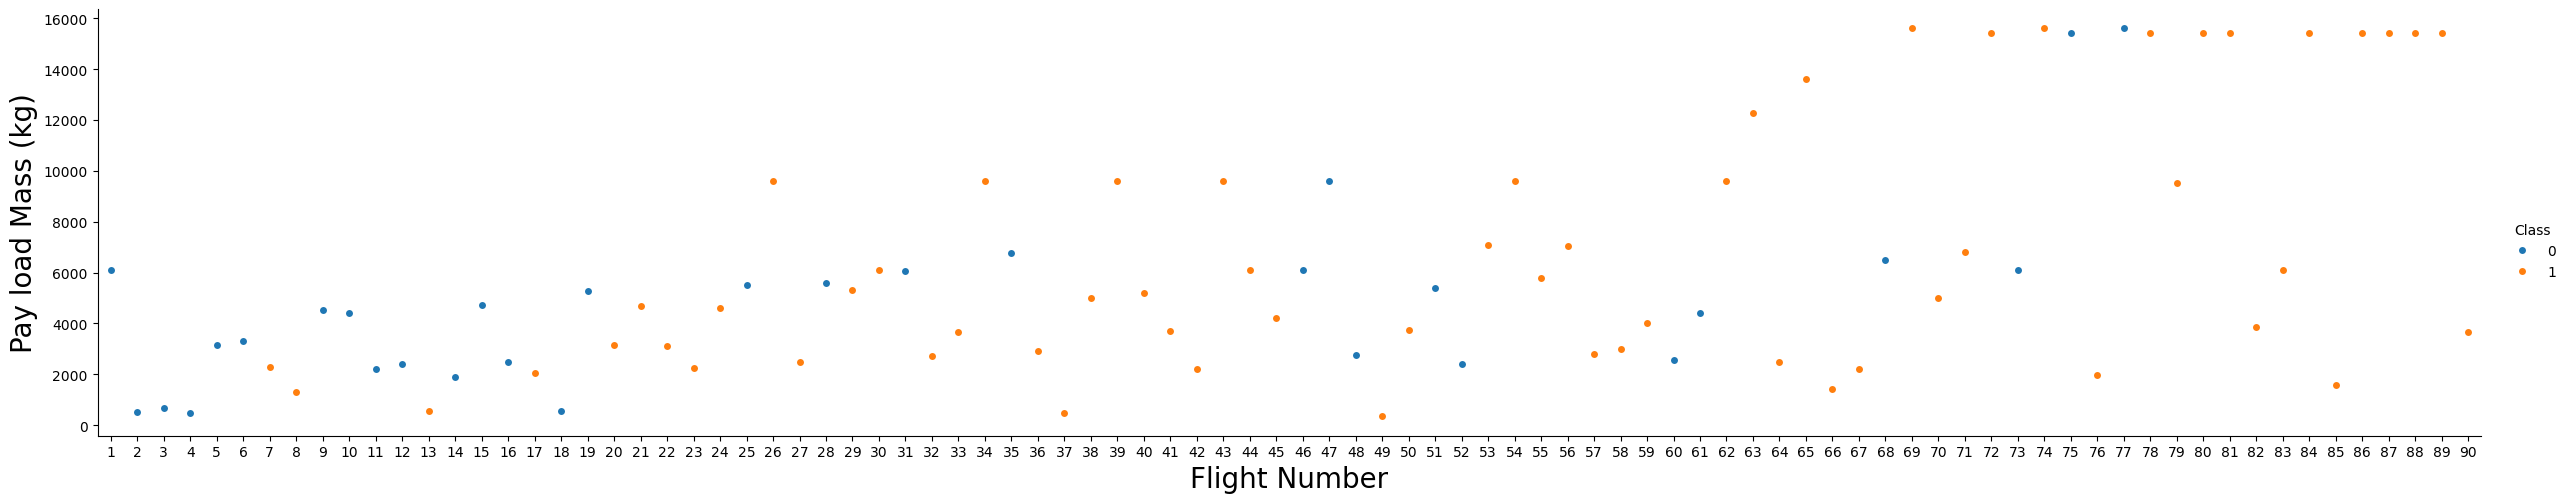

In [6]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

Next, let's drill down to each site visualize its detailed launch records.<br>
A continuación, profundicemos en cada sitio y visualicemos sus registros de lanzamiento detallados.


### TASK 1: Visualize the relationship between Flight Number and Launch Site
TAREA 1: Visualizar la relación entre el número de vuelo y el sitio de lanzamiento

Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code><br>
Utilice la función <code>catplot</code> para trazar <code>FlightNumber</code> frente a <code>LaunchSite</code>, establezca el parámetro <code>x</code> en <code>FlightNumber</code>, establezca <code>y</code> en <code>Launch Site</code> y establezca el parámetro <code>hue</code> en <code>'class'</code>.


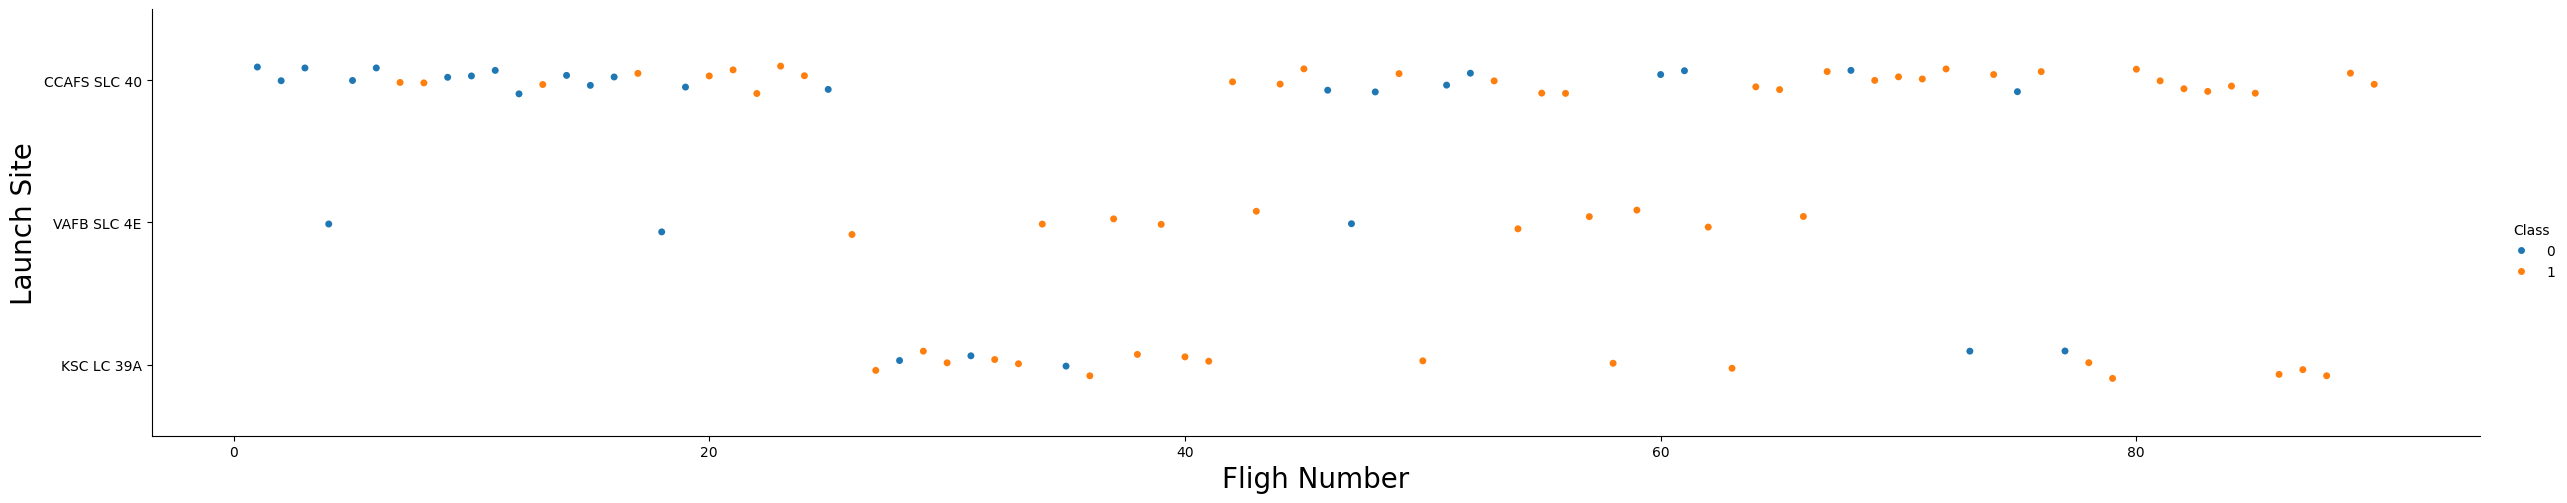

In [10]:
# Plot a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value
# Trazar un gráfico de puntos de dispersión con el eje x como número de vuelo, el eje y como el sitio de lanzamiento y el tono como el valor de clase

sns.catplot(y="LaunchSite", x='FlightNumber',hue='Class',data=df,aspect=5)
plt.xlabel("Fligh Number",fontsize=20)
plt.ylabel("Launch Site",fontsize=20)
plt.show()

Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.<br>
Ahora intente explicar los patrones que encontró en los gráficos de puntos de dispersión del número de vuelo frente al sitio de lanzamiento.


### TASK 2: Visualize the relationship between Payload Mass and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.<br>
También queremos observar si existe alguna relación entre los sitios de lanzamiento y su masa de carga útil.


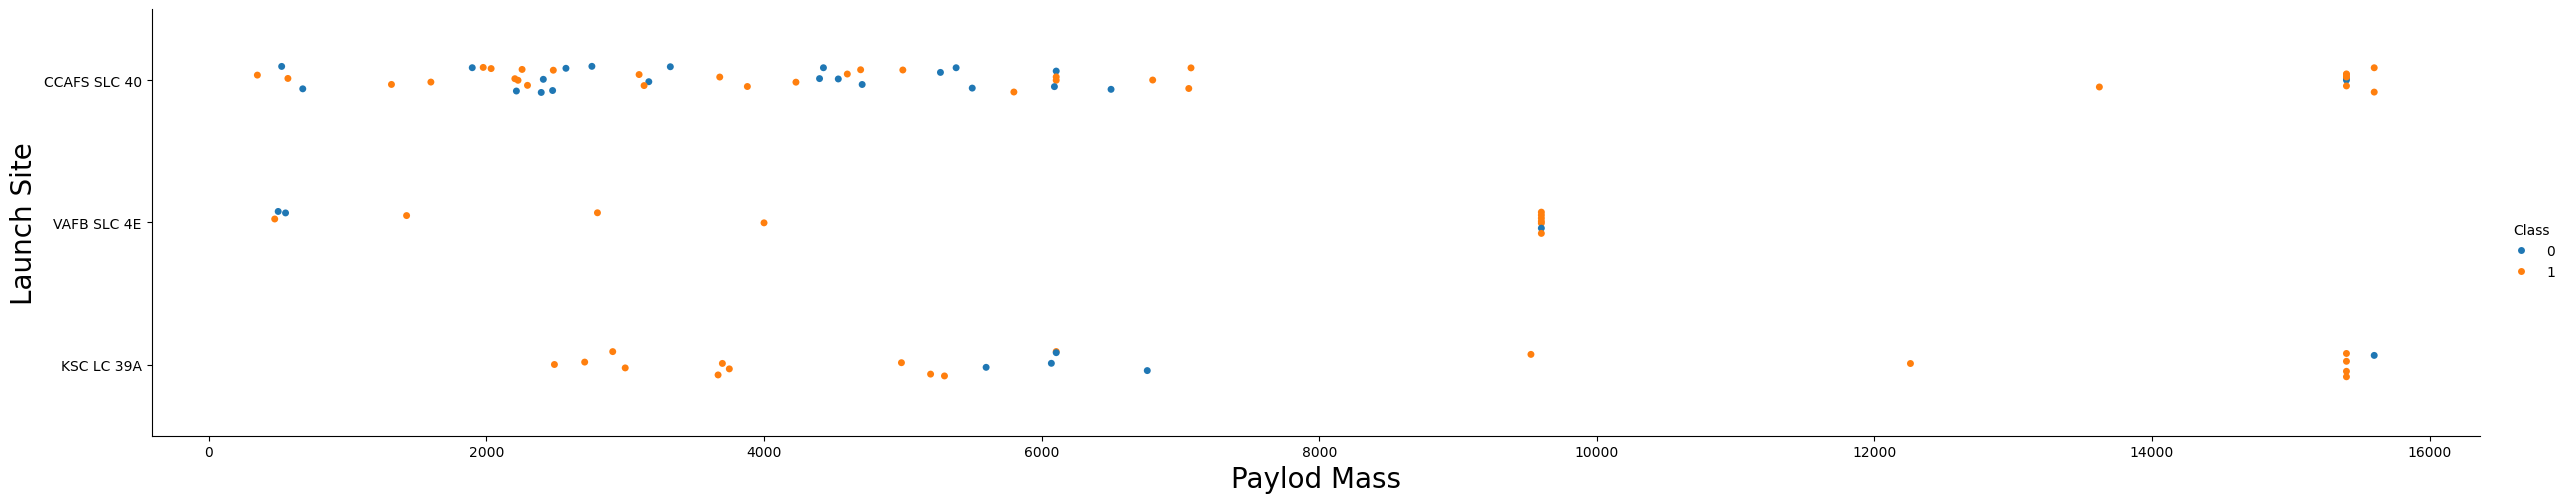

In [11]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value
# Trace un gráfico de puntos de dispersión con el eje x como masa de carga útil (kg), el eje y como el sitio de lanzamiento y el tono como el valor de clase.

sns.catplot(y='LaunchSite',x='PayloadMass',hue='Class',data=df,aspect=5)
plt.xlabel("Paylod Mass",fontsize=20)
plt.ylabel("Launch Site",fontsize=20)
plt.show()



Now if you observe Payload Mass Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).<br>
Ahora bien, si observa la masa de carga útil vs. En el gráfico de puntos de dispersión del sitio de lanzamiento que encontrará para el sitio de lanzamiento VAFB-SLC, no se lanzan cohetes con una masa de carga pesada (superior a 10000).


### TASK  3: Visualize the relationship between success rate of each orbit type
TAREA 3: Visualizar la relación entre la tasa de éxito de cada tipo de órbita

Next, we want to visually check if there are any relationship between success rate and orbit type.
<br>
A continuación, queremos comprobar visualmente si existe alguna relación entre la tasa de éxito y el tipo de órbita.

Let's create a `bar chart` for the sucess rate of each orbit
<br>
Creemos un "gráfico de barras" para la tasa de éxito de cada órbita.

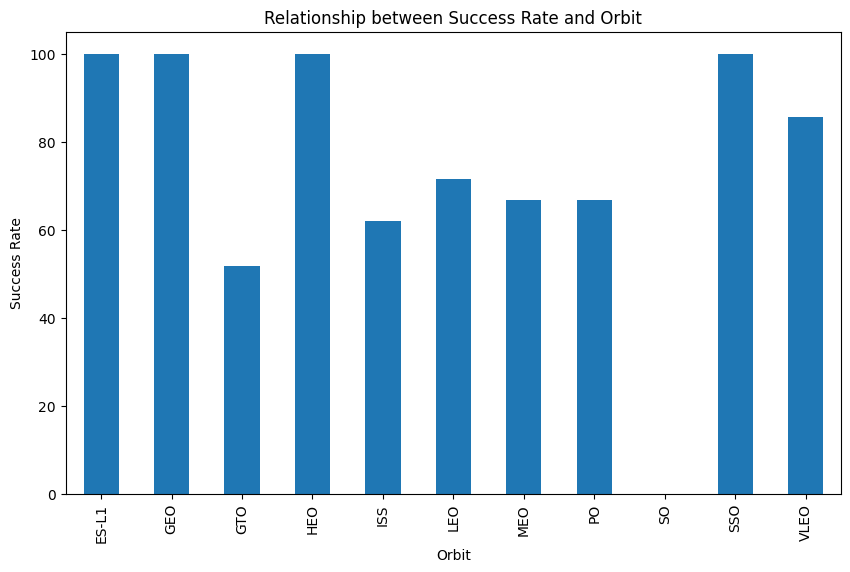

In [13]:
# HINT use groupby method on Orbit column and get the mean of Class column
# SUGERENCIA use el método groupby en la columna Orbit y obtenga la media de la columna 

df_success=df.groupby('Orbit')['Class'].mean()*100
df_success.plot(kind='bar', figsize=(10,6))

plt.xlabel('Orbit') 
plt.ylabel('Success Rate') 
plt.title('Relationship between Success Rate and Orbit') 

plt.show()

Analyze the plotted bar chart to identify which orbits have the highest success rates.
<br>
Analice el gráfico de barras trazado para identificar qué órbitas tienen las tasas de éxito más altas.


### TASK  4: Visualize the relationship between FlightNumber and Orbit type
TAREA 4: Visualizar la relación entre FlightNumber y tipo de órbita

For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.<br>
Para cada órbita, queremos ver si existe alguna relación entre FlightNumber y el tipo de órbita.


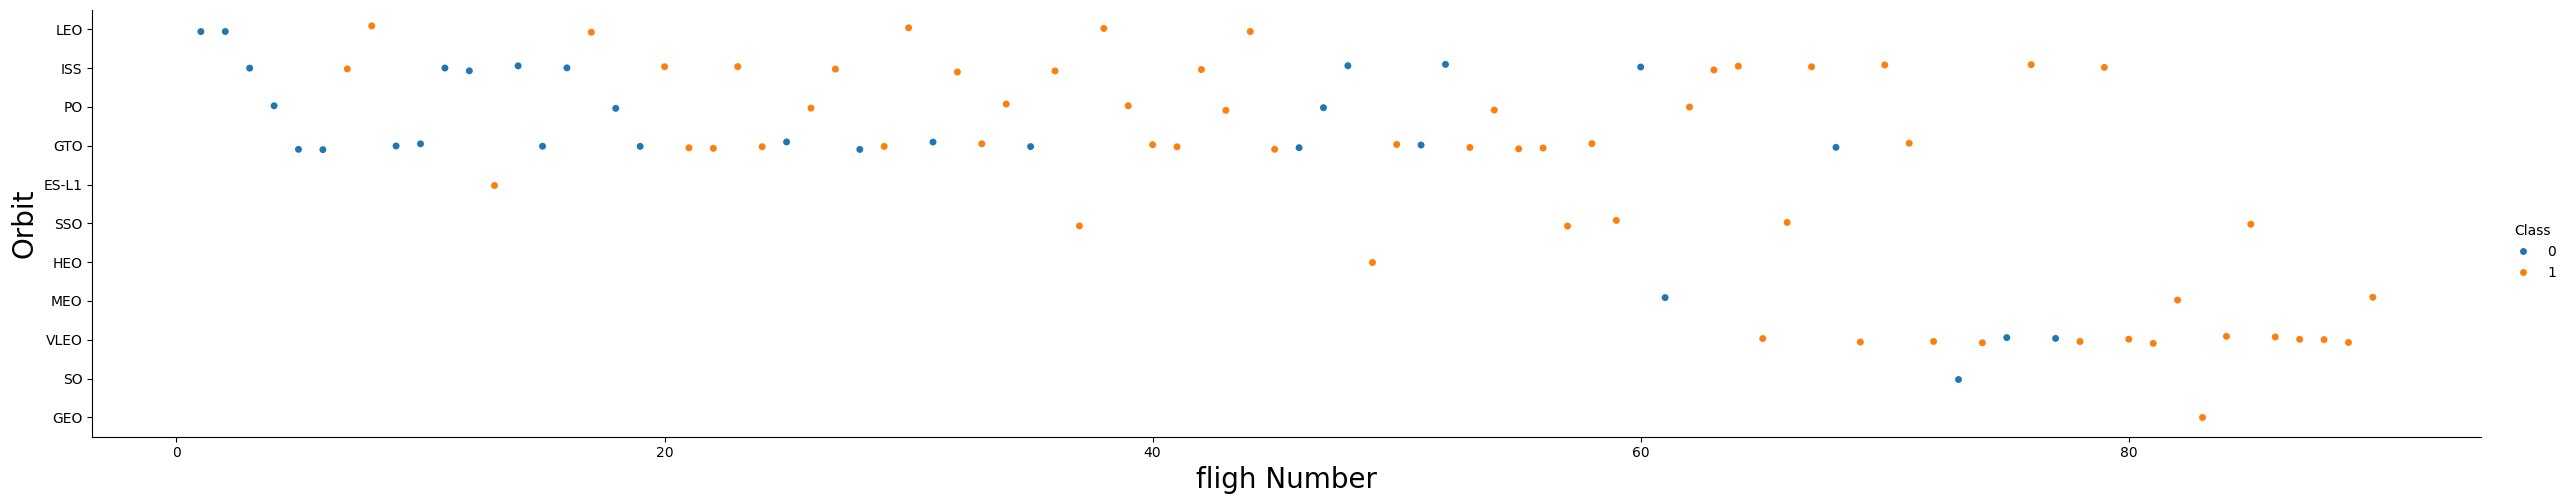

In [15]:
# Plot a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value
# Trazar un gráfico de puntos de dispersión con el eje x como FlightNumber y el eje y como la órbita, y el tono como el valor de clase

sns.catplot(y='Orbit',x='FlightNumber',hue='Class',data=df,aspect=5)
plt.xlabel("fligh Number",fontsize=20)
plt.ylabel("Orbit",fontsize=20)
plt.show()


You can observe that in the LEO orbit, success seems to be related to the number of flights. Conversely, in the GTO orbit, there appears to be no relationship between flight number and success.<br>
Se puede observar que en la órbita LEO, el éxito parece estar relacionado con el número de vuelos. Por el contrario, en la órbita GTO, no parece haber relación entre el número de vuelos y el éxito.


### TASK  5: Visualize the relationship between Payload Mass and Orbit type
TAREA 5: Visualizar la relación entre la masa de carga útil y el tipo de órbita

Similarly, we can plot the Payload Mass vs. Orbit scatter point charts to reveal the relationship between Payload Mass and Orbit type
<br>
De manera similar, podemos trazar los gráficos de puntos de dispersión de la masa de la carga útil frente a la órbita para revelar la relación entre la masa de la carga útil y el tipo de órbita.

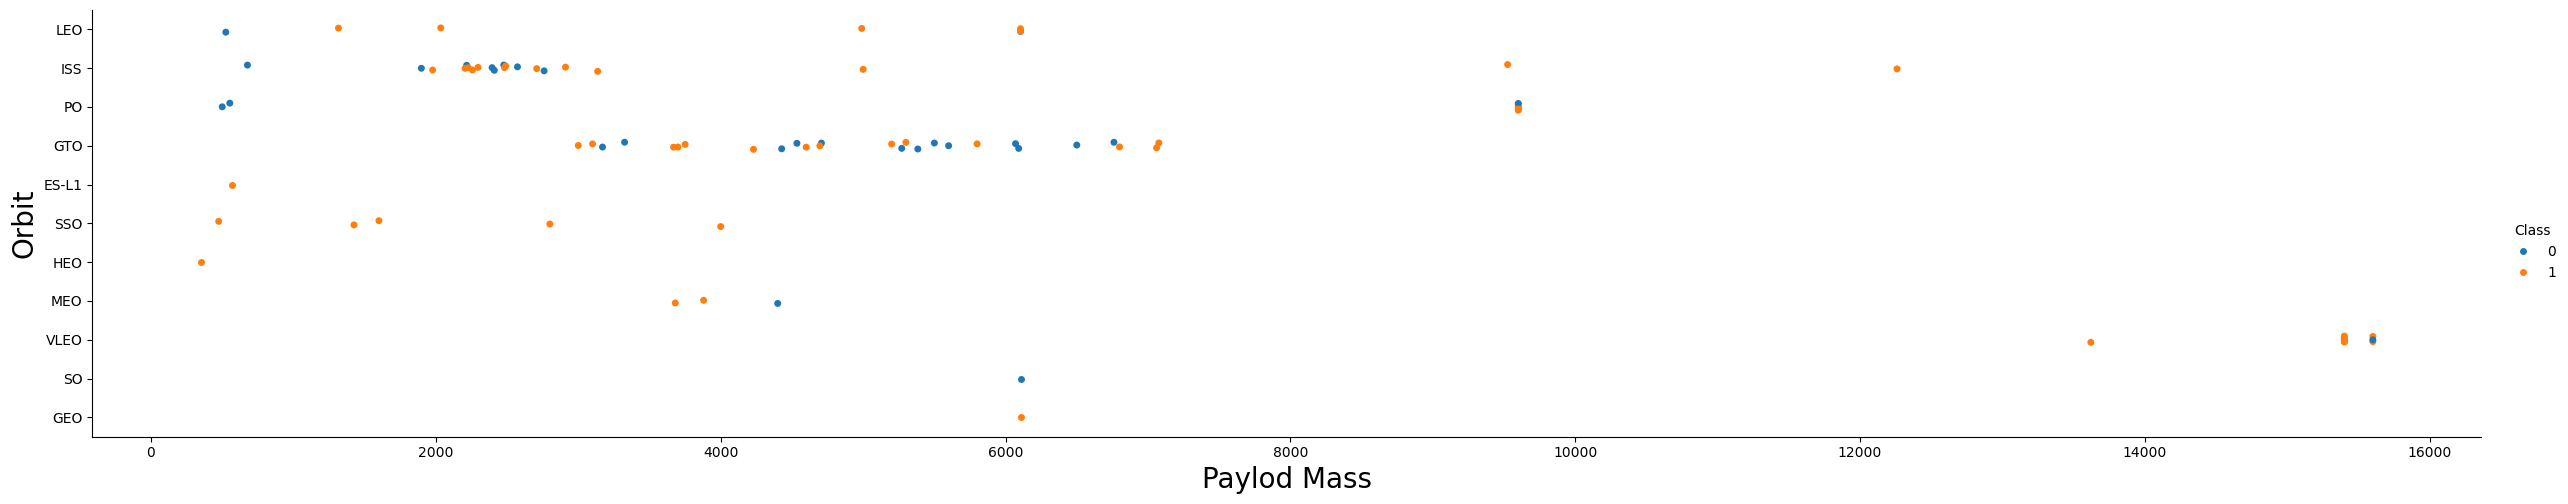

In [16]:
# Plot a scatter point chart with x axis to be Payload Mass and y axis to be the Orbit, and hue to be the class value
# Trazar un gráfico de puntos de dispersión con el eje x como masa de carga útil, el eje y como órbita y el tono como valor de clase

sns.catplot(y='Orbit',x='PayloadMass',hue='Class',data=df,aspect=5)
plt.xlabel("Paylod Mass",fontsize=20)
plt.ylabel("Orbit",fontsize=20)
plt.show()

With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.
However, for GTO, it's difficult to distinguish between successful and unsuccessful landings as both outcomes are present.
<br>
Con cargas útiles pesadas, la tasa de aterrizaje exitoso o positivo es mayor para Polar, LEO e ISS.
Sin embargo, para GTO, es difícil distinguir entre aterrizajes exitosos y no exitosos, ya que ambos resultados están presentes.


### TASK  6: Visualize the launch success yearly trend
TAREA 6: Visualizar la tendencia anual de éxito del lanzamiento

You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend.<br>
Puede trazar un gráfico de líneas con el eje x como <code>Año</code> y el eje y como la tasa de éxito promedio, para obtener la tendencia promedio de éxito de lanzamiento.

The function will help you get the year from the date:<br>
La función le ayudará a obtener el año a partir de la fecha:

In [17]:
# A function to Extract years from the date 
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()
    

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


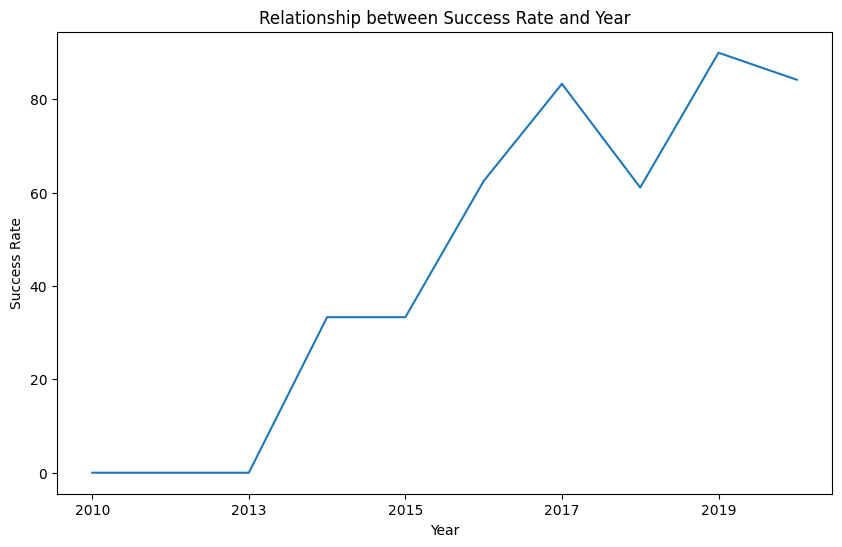

In [20]:
# Plot a line chart with x axis to be the extracted year and y axis to be the success rate
# Trazar un gráfico de líneas con el eje x como el año extraído y el eje y como la tasa de éxito

Extract_year()
#df['Date']=year
fig,ax=plt.subplots()
df_success1=df.groupby('Date')['Class'].mean()*100
df_success1.plot(kind='line', figsize=(10,6))

plt.xlabel('Year') 
plt.ylabel('Success Rate') 
plt.title('Relationship between Success Rate and Year')

plt.show()


you can observe that the sucess rate since 2013 kept increasing till 2020
<br>
Se puede observar que la tasa de éxito desde 2013 siguió aumentando hasta 2020.

## Features Engineering


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.
<br>
A estas alturas, debería obtener algunos conocimientos preliminares sobre cómo cada variable importante afectaría la tasa de éxito; seleccionaremos las características que se utilizarán en la predicción del éxito en el módulo futuro.


In [21]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### TASK  7: Create dummy variables to categorical columns
TAREA 7: Crear variables ficticias para columnas categóricas

Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.

Utilice la función <code>get_dummies</code> y el marco de datos <code>features</code> para aplicar OneHotEncoder a la columna <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code> y <code>Serial</code>. Asigne el valor a la variable <code>features_one_hot</code>, muestre los resultados usando el encabezado del método. Su marco de datos de resultados debe incluir todas las funciones, incluidas las codificadas.


In [22]:
# HINT: Use get_dummies() function on the categorical columns
# SUGERENCIA: Utilice la función get_dummies() en las columnas categóricas


features_one_hot=pd.get_dummies(features, prefix=['Orbits','LaunchSite','LandingPad','Serial'])
features_one_hot.head()


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbits_ES-L1,Orbits_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TASK  8: Cast all numeric columns to `float64`
TAREA 8: Transmitir todas las columnas numéricas a `float64`

Now that our <code>features_one_hot</code> dataframe only contains numbers, cast the entire dataframe to variable type <code>float64</code><br>
Ahora que nuestro marco de datos <code>features_one_hot</code> solo contiene números, convierta todo el marco de datos al tipo de variable <code>float64</code>


In [23]:
# HINT: use astype function
# SUGERENCIA: utilice la función astype

features_one_hot.astype('float64')

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbits_ES-L1,Orbits_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,1.0,1.0,1.0,5.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
86,87.0,15400.000000,3.0,1.0,1.0,1.0,5.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
87,88.0,15400.000000,6.0,1.0,1.0,1.0,5.0,5.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
88,89.0,15400.000000,3.0,1.0,1.0,1.0,5.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range.

Ahora podemos exportarlo a un <b>CSV</b> para la siguiente sección, pero para que las respuestas sean consistentes, en la próxima práctica de laboratorio proporcionaremos datos en un rango de fechas preseleccionado.


<code>features_one_hot.to_csv('dataset_part\_3.csv', index=False)</code>


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log-->


<!--
| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|
| 2024-07-18        | 1.2     | Anita Verma | Clarified instructions|
-->


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
